In [1]:
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import binary_dilation
from skimage.transform import rotate
import os
import numpy as np
import matplotlib.pyplot as plt
import pathlib

import numpy as np
import tifffile as tiff
from skimage.transform import resize
import tensorflow as tf
from skimage.draw import ellipse
from skimage import util
from skimage.io import imread
from skimage.color import rgb2hsv, rgb2gray
from skimage.filters import gaussian, threshold_triangle, threshold_otsu, threshold_li, threshold_isodata, threshold_minimum, try_all_threshold, threshold_mean, median
from skimage.exposure import adjust_gamma
from skimage.feature import structure_tensor
from skimage.segmentation import expand_labels, flood, clear_border
from skimage.measure import label,  regionprops_table, find_contours
from skimage.morphology import remove_small_holes, closing, disk, square,opening, remove_small_objects, rectangle, erosion
from skimage import exposure, feature

from skimage.measure import label, regionprops, moments_central
from scipy.ndimage import binary_erosion, rotate, binary_opening, binary_dilation
from scipy.ndimage import distance_transform_edt
from scipy.interpolate import splprep, splev
from skimage.draw import polygon
import tifffile

import tensorflow as tf
from pathlib import Path
import numpy as np
import tifffile as tiff

# Traditional Methods


In [2]:
unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\max_projections\unseen_images")
tif_files = list(unseen_image_folder.glob("*.tif"))
i = 5
img = imread(tif_files[i]).astype(np.float32)
print(img.max(), img.min())

255.0 0.0


In [3]:
img.shape

(4692, 2859)

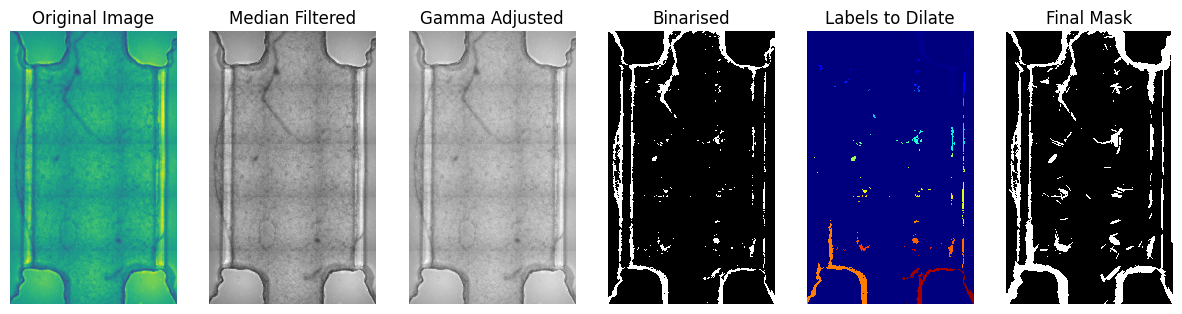

In [4]:
def signed_orientation(region):
    img = region.image.astype(float)
    mu = moments_central(img)
    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]
    angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
    return np.rad2deg(angle_rad)

median_img = median(img, footprint=disk(5))   # try disk(1..3)

adjusted = adjust_gamma((median_img), gamma=0.7, gain=1)
thresh = threshold_triangle(adjusted)
binary = adjusted > thresh
inverted = util.invert(binary)

labels = label(inverted)

data = regionprops_table(labels, binary, properties=("label", "area", "eccentricity"))  
condition = (data['area'] > 200) & (data['area'] < 200000) & (data['eccentricity'] > 0.5)
labels_to_dilate = util.map_array(labels, data['label'], data['label'] * condition) 
dilated_output = np.zeros_like(labels, dtype=np.uint8)

for region in regionprops(labels_to_dilate):
    region_label = region.label
    mask = labels_to_dilate == region_label
    angle_to_rotate = signed_orientation(region)
    selem = np.zeros((101, 101), dtype=bool)
    selem[51, :] = 1
    rotated_selem = rotate(selem.astype(float), angle=90 + angle_to_rotate, reshape=False, order=0) > 0.5
    dilated = binary_dilation(mask, structure=rotated_selem)
    dilated_output[dilated] = 255
final_mask = np.logical_or(dilated_output, inverted)


fig, ax = plt.subplots(ncols=6, figsize=(15,5))
titles = ['Original Image', 'Median Filtered', "Gamma Adjusted", 'Binarised', 'Labels to Dilate', 'Final Mask']
ax[0].imshow(img)
ax[1].imshow(median_img, interpolation = "none", cmap='gray')
ax[2].imshow(adjusted, interpolation = "none", cmap='gray')
ax[3].imshow(inverted, interpolation = "none", cmap='gray')
ax[4].imshow(labels_to_dilate, interpolation = "none", cmap="jet")
ax[5].imshow(final_mask, interpolation = "none", cmap='gray')
for i, axis in enumerate(ax):
    ax[i].axis('off')
    ax[i].set_title(titles[i])

In [19]:
from pathlib import Path
import numpy as np
import tensorflow as tf
import tifffile as tiff

# -----------------------------
# Paths
# -----------------------------
IMG_DIR = Path(r"Z:\Bel\Vascumap_Example_Lifs\max_projections\minimal_priorities\downsampled4\images")
LAB_DIR = Path(r"Z:\Bel\Vascumap_Example_Lifs\max_projections\minimal_priorities\downsampled4\labels")

# -----------------------------
# Config
# -----------------------------
PATCH = 512
BATCH = 4
EPOCHS = 120
LR = 3e-4

PATCHES_PER_IMAGE_TRAIN = 96
PATCHES_PER_IMAGE_VAL   = 32

# Sampling mix (device covers large area -> oversample boundary)
P_BOUNDARY   = 0.65
P_BACKGROUND = 0.20
P_INTERIOR   = 0.15

# Loss weighting (tune these)
BOUNDARY_WEIGHT = 4   # 5–12 typical
BG_WEIGHT       = 1.2   # 1.5–3 typical
BAND_RADIUS     = 2    # pixels, 2–5 typical

AUTOTUNE = tf.data.AUTOTUNE


# -----------------------------
# Pairing
# -----------------------------
def list_pairs(img_dir: Path, lab_dir: Path, label_suffix="_labels"):
    img_paths = sorted(img_dir.glob("*.tif*"))
    pairs = []
    missing = []
    for ip in img_paths:
        # common extensions
        candidates = [
            lab_dir / f"{ip.stem}{label_suffix}.tif",
            lab_dir / f"{ip.stem}{label_suffix}.tiff",
            lab_dir / f"{ip.stem}{label_suffix}.TIF",
            lab_dir / f"{ip.stem}{label_suffix}.TIFF",
        ]
        lp = next((c for c in candidates if c.exists()), None)
        if lp is None:
            alt = list(lab_dir.glob(f"{ip.stem}{label_suffix}.tif*"))
            lp = alt[0] if alt else None

        if lp is None:
            missing.append(ip.name)
        else:
            pairs.append((ip, lp))

    if missing:
        print("WARNING: images with no matching label:", missing[:10], ("..." if len(missing) > 10 else ""))
    print(f"Found {len(pairs)} paired image/label files.")
    return pairs


# -----------------------------
# TIFF loading (strict 2D)
# -----------------------------
def load_image(path: Path) -> np.ndarray:
    img = np.squeeze(tiff.imread(str(path)))
    if img.ndim != 2:
        raise ValueError(f"{path.name}: expected 2D image, got {img.shape}")
    return img.astype(np.float32)

def load_mask(path: Path) -> np.ndarray:
    m = np.squeeze(tiff.imread(str(path)))
    if m.ndim != 2:
        raise ValueError(f"{path.name}: expected 2D mask, got {m.shape}")
    # accept {0,1} or {0,255} etc.
    return (m > 0).astype(np.uint8)


# -----------------------------
# Patch sampling (always returns PATCH x PATCH via padding)
# -----------------------------
def compute_boundary(mask: np.ndarray) -> np.ndarray:
    mp = np.pad(mask.astype(np.uint8), 1, mode="edge")
    c = mp[1:-1, 1:-1]
    return (
        (mp[:-2, :-2] != c) | (mp[:-2, 1:-1] != c) | (mp[:-2, 2:] != c) |
        (mp[1:-1, :-2] != c) |                        (mp[1:-1, 2:] != c) |
        (mp[2:, :-2] != c)  | (mp[2:, 1:-1] != c)  | (mp[2:, 2:] != c)
    )

def sample_patch(img: np.ndarray, mask: np.ndarray, patch: int):
    H, W = img.shape
    ph = pw = patch

    boundary = compute_boundary(mask)
    bg = mask == 0
    interior = (mask == 1) & (~boundary)

    r = np.random.rand()
    if r < P_BOUNDARY and boundary.any():
        ys, xs = np.where(boundary)
    elif r < P_BOUNDARY + P_BACKGROUND and bg.any():
        ys, xs = np.where(bg)
    else:
        if interior.any():
            ys, xs = np.where(interior)
        elif (mask == 1).any():
            ys, xs = np.where(mask == 1)
        else:
            ys, xs = np.array([H // 2]), np.array([W // 2])

    i = np.random.randint(len(ys))
    cy, cx = int(ys[i]), int(xs[i])

    # desired window
    y0 = cy - ph // 2
    x0 = cx - pw // 2
    y1 = y0 + ph
    x1 = x0 + pw

    # clip to image
    y0c = max(0, y0)
    x0c = max(0, x0)
    y1c = min(H, y1)
    x1c = min(W, x1)

    img_p = img[y0c:y1c, x0c:x1c]
    msk_p = mask[y0c:y1c, x0c:x1c]

    # pad to patch size if needed
    pad_top = y0c - y0
    pad_left = x0c - x0
    pad_bottom = y1 - y1c
    pad_right = x1 - x1c

    if pad_top or pad_left or pad_bottom or pad_right:
        img_p = np.pad(img_p, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="reflect")
        msk_p = np.pad(msk_p, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0)

    if img_p.shape != (ph, pw) or msk_p.shape != (ph, pw):
        raise ValueError(f"Bad patch shape img={img_p.shape}, msk={msk_p.shape}, from image {img.shape}")

    return img_p.astype(np.float32), msk_p.astype(np.uint8)


# -----------------------------
# Fast normalization
# -----------------------------
def fast_normalize(img):
    # img: [H,W,1]
    img = tf.cast(img, tf.float32)
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    img = (img - mean) / tf.maximum(std, 1e-6)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return (img + 3.0) / 6.0


# -----------------------------
# Augmentation
# -----------------------------
def augment(img, msk):
    if tf.random.uniform([]) < 0.5:
        img = tf.image.flip_left_right(img)
        msk = tf.image.flip_left_right(msk)
    if tf.random.uniform([]) < 0.5:
        img = tf.image.flip_up_down(img)
        msk = tf.image.flip_up_down(msk)

    k = tf.random.uniform([], 0, 4, tf.int32)
    img = tf.image.rot90(img, k)
    msk = tf.image.rot90(msk, k)

    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.7, 1.3)

    gamma = tf.random.uniform([], 0.7, 1.6)
    img = tf.pow(tf.clip_by_value(img, 0.0, 1.0), gamma)

    noise = tf.random.normal(tf.shape(img), stddev=0.03)
    img = tf.clip_by_value(img + noise, 0.0, 1.0)
    return img, msk


# -----------------------------
# Boundary band + weight map (TF)
# -----------------------------
def _dilate(x, r):
    k = 2 * r + 1
    x4 = tf.expand_dims(x, 0)  # [1,H,W,1]
    y = tf.nn.max_pool2d(x4, ksize=k, strides=1, padding="SAME")
    return tf.squeeze(y, 0)

def _erode(x, r):
    return 1.0 - _dilate(1.0 - x, r)

def boundary_band(mask01, r=BAND_RADIUS):
    d = _dilate(mask01, r)
    e = _erode(mask01, r)
    band = tf.clip_by_value(d - e, 0.0, 1.0)
    return tf.cast(band > 0.0, tf.float32)

def make_weight_map(mask01):
    band = boundary_band(mask01, r=BAND_RADIUS)
    bg = 1.0 - mask01
    w = 1.0 + (BOUNDARY_WEIGHT - 1.0) * band + (BG_WEIGHT - 1.0) * bg
    return w


# -----------------------------
# Dataset (packs y_true as [mask, weight])
# -----------------------------
def make_dataset(pairs, patches_per_image, training=True):
    def gen():
        for ip, lp in pairs:
            img = load_image(ip)
            msk = load_mask(lp)
            for _ in range(patches_per_image):
                yield sample_patch(img, msk, PATCH)

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec((PATCH, PATCH), tf.float32),
            tf.TensorSpec((PATCH, PATCH), tf.uint8),
        )
    )

    def prep(img, msk):
        img = tf.expand_dims(img, -1)  # [PATCH,PATCH,1]
        msk = tf.expand_dims(tf.cast(msk, tf.float32), -1)  # [PATCH,PATCH,1]

        img = tf.ensure_shape(img, (PATCH, PATCH, 1))
        msk = tf.ensure_shape(msk, (PATCH, PATCH, 1))

        img = fast_normalize(img)
        if training:
            img, msk = augment(img, msk)

        w = make_weight_map(msk)               # [PATCH,PATCH,1]
        y = tf.concat([msk, w], axis=-1)       # [PATCH,PATCH,2]
        y = tf.ensure_shape(y, (PATCH, PATCH, 2))
        return img, y

    if training:
        ds = ds.shuffle(2048)
    ds = ds.map(prep, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds


# -----------------------------
# U-Net
# -----------------------------
def conv_block(x, f):
    x = tf.keras.layers.Conv2D(f, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Conv2D(f, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    return x

def build_unet():
    inputs = tf.keras.Input((PATCH, PATCH, 1))
    c1 = conv_block(inputs, 32)
    p1 = tf.keras.layers.MaxPool2D()(c1)
    c2 = conv_block(p1, 64)
    p2 = tf.keras.layers.MaxPool2D()(c2)
    c3 = conv_block(p2, 128)
    p3 = tf.keras.layers.MaxPool2D()(c3)
    c4 = conv_block(p3, 256)
    p4 = tf.keras.layers.MaxPool2D()(c4)

    bn = conv_block(p4, 512)
    bn = tf.keras.layers.Dropout(0.3)(bn)

    u4 = tf.keras.layers.UpSampling2D()(bn)
    u4 = tf.keras.layers.Concatenate()([u4, c4])
    u4 = conv_block(u4, 256)

    u3 = tf.keras.layers.UpSampling2D()(u4)
    u3 = tf.keras.layers.Concatenate()([u3, c3])
    u3 = conv_block(u3, 128)

    u2 = tf.keras.layers.UpSampling2D()(u3)
    u2 = tf.keras.layers.Concatenate()([u2, c2])
    u2 = conv_block(u2, 64)

    u1 = tf.keras.layers.UpSampling2D()(u2)
    u1 = tf.keras.layers.Concatenate()([u1, c1])
    u1 = conv_block(u1, 32)

    out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(u1)
    return tf.keras.Model(inputs, out)


# -----------------------------
# Loss / metric (uses y_true[...,0]=mask, y_true[...,1]=weight)
# -----------------------------
def dice_coef(y_true_packed, y_pred, eps=1e-6):
    y_true = tf.cast(y_true_packed[..., 0:1], tf.float32)
    y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 0.0, 1.0)
    num = 2.0 * tf.reduce_sum(y_true * y_pred) + eps
    den = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + eps
    return num / den

def dice_loss(y_true_packed, y_pred):
    return 1.0 - dice_coef(y_true_packed, y_pred)

def weighted_bce_dice_loss(y_true_packed, y_pred):
    y_true = tf.cast(y_true_packed[..., 0:1], tf.float32)
    w      = tf.cast(y_true_packed[..., 1:2], tf.float32)

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)  # [B,H,W]
    bce = tf.expand_dims(bce, axis=-1)                         # [B,H,W,1]

    wbce = tf.reduce_sum(bce * w) / tf.maximum(tf.reduce_sum(w), 1e-6)
    return wbce + dice_loss(y_true_packed, y_pred)


# -----------------------------
# Train
# -----------------------------
pairs = list_pairs(IMG_DIR, LAB_DIR, label_suffix="_labels")

rng = np.random.default_rng(0)
idx = np.arange(len(pairs))
rng.shuffle(idx)

n_val = max(6, int(0.2 * len(pairs)))
val_pairs = [pairs[i] for i in idx[:n_val]]
train_pairs = [pairs[i] for i in idx[n_val:]]

print(f"Train images: {len(train_pairs)} | Val images: {len(val_pairs)}")

train_ds = make_dataset(train_pairs, PATCHES_PER_IMAGE_TRAIN, training=True)
val_ds   = make_dataset(val_pairs, PATCHES_PER_IMAGE_VAL, training=False)

model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss=weighted_bce_dice_loss,
    metrics=[dice_coef],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "device_unet_boundaryweighted_best.keras", monitor="val_dice_coef", mode="max", save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef", mode="max", patience=20, restore_best_weights=True
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

model.save("device_unet_boundaryweighted_final2.keras")
print("Saved: device_unet_boundaryweighted_best.keras and device_unet_boundaryweighted_final2.keras")


Found 41 paired image/label files.
Train images: 33 | Val images: 8
Epoch 1/120
792/792 [==============================] - 128s 104ms/step - loss: 0.8977 - dice_coef: 0.6406 - val_loss: 1.6949 - val_dice_coef: 0.2710 - lr: 3.0000e-04
Epoch 2/120
792/792 [==============================] - 127s 101ms/step - loss: 0.7326 - dice_coef: 0.7126 - val_loss: 0.9960 - val_dice_coef: 0.5387 - lr: 3.0000e-04
Epoch 3/120
792/792 [==============================] - 121s 100ms/step - loss: 0.6625 - dice_coef: 0.7433 - val_loss: 3.9839 - val_dice_coef: 0.0076 - lr: 3.0000e-04
Epoch 4/120
792/792 [==============================] - 125s 105ms/step - loss: 0.6286 - dice_coef: 0.7560 - val_loss: 0.7154 - val_dice_coef: 0.7281 - lr: 3.0000e-04
Epoch 5/120
792/792 [==============================] - 125s 102ms/step - loss: 0.6187 - dice_coef: 0.7593 - val_loss: 1.2484 - val_dice_coef: 0.4611 - lr: 3.0000e-04
Epoch 6/120
792/792 [==============================] - 128s 104ms/step - loss: 0.5946 - dice_coef: 0.7

Z:\Bel\Vascumap_Example_Lifs\max_projections\unseen_images\20250619_vascumap_dev25_11_img6_maxproj.ome.tif
1/1 [==============================] - 0s 254ms/step
pred_in min/max/mean: 0.0063470639288425446 0.9693641662597656 0.4045558571815491
pred_in min/max/mean: 0.0063470639288425446 0.9693641662597656 0.4045558571815491


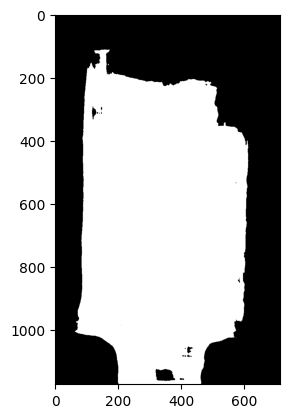

In [22]:


TARGET_H, TARGET_W = 512, 512
DS = 4

# load model
model = tf.keras.models.load_model("device_unet_boundaryweighted_final2.keras", compile=False)

unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\max_projections\unseen_images")
tif_files = list(unseen_image_folder.glob("*.tif"))
i=7
img_path = tif_files[i]
print(img_path)
img_full = tiff.imread(tif_files[i])
# downsample x4 (same as your dataset)
h, w = img_full.shape
h_ds, w_ds = h // DS, w // DS

img_ds = resize(
    img_full, (h_ds, w_ds),
    order=1, preserve_range=True, anti_aliasing=True
).astype(np.float32)

# normalize (same style as training)
p1, p99 = np.percentile(img_ds, [1, 99])
img_ds = np.clip((img_ds - p1) / (p99 - p1 + 1e-6), 0, 1)

# IMPORTANT: resize to model input size
img_in = resize(
    img_ds, (TARGET_H, TARGET_W),
    order=1, preserve_range=True, anti_aliasing=True
).astype(np.float32)

x = img_in[None, ..., None]  # (1, 512, 512, 1)

# predict
pred_in = model.predict(x)[0, ..., 0]  # (512, 512) probabilities
print("pred_in min/max/mean:", float(pred_in.min()), float(pred_in.max()), float(pred_in.mean()))

# resize prediction back to downsampled size
pred_ds = resize(
    pred_in, (h_ds, w_ds),
    order=1, preserve_range=True, anti_aliasing=True
).astype(np.float32)
print("pred_in min/max/mean:", float(pred_in.min()), float(pred_in.max()), float(pred_in.mean()))


mask_ds = (pred_ds > 0.3).astype(np.uint8)
plt.imshow(mask_ds, cmap='gray')



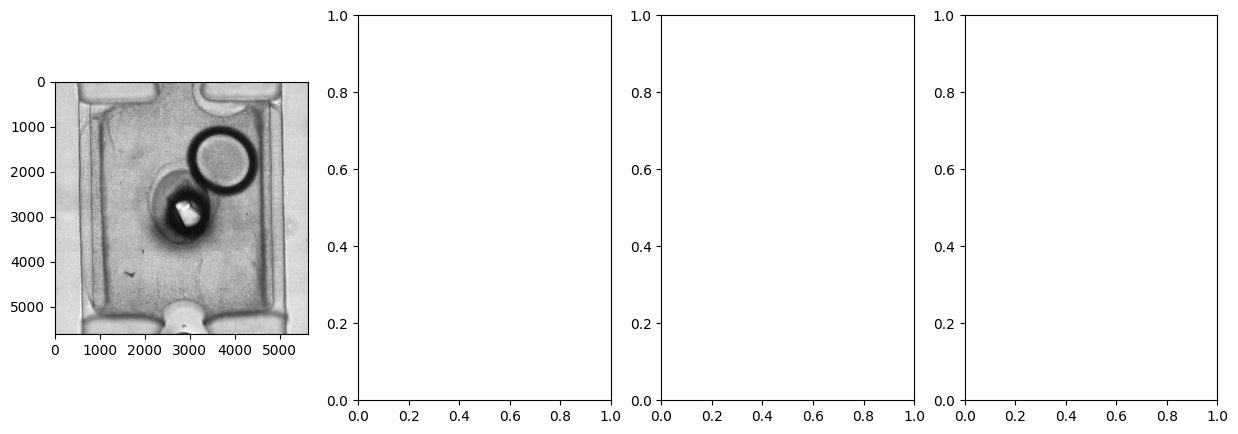

In [10]:

# upsample mask back to full-res (nearest!)
mask_full = resize(
    mask_ds, (h, w),
    order=0, preserve_range=True, anti_aliasing=False
).astype(np.uint8)
clean_mask = remove_small_objects(mask_full.astype(bool), min_size=20000)
clean_mask = remove_small_holes(clean_mask, area_threshold=20000)
# clean_mask = closing(clean_mask, square(100))
# save
# out_path = img_path.with_name(img_path.stem + "_pred_mask.tif")
# tiff.imwrite(out_path, mask_full)
# print("Saved:", out_path)
labelled_device = label(clean_mask)
fig, ax = plt.subplots(1,4, figsize=(15,5))
ax[0].imshow(img_full, cmap='gray')
# ax[1].imshow(mask_full, cmap='gray')
# ax[2].imshow(clean_mask, cmap="gray")
# ax[3].imshow(img_full, cmap='gray')
# ax[3].imshow(np.ma.masked_where(labelled_device == 0, labelled_device), cmap="jet", alpha=0.5, interpolation="none")


In [5]:
import numpy as np
from scipy.ndimage import distance_transform_edt
from skimage.measure import moments_central
from skimage.transform import rotate

# -----------------------------
# Helpers
# -----------------------------
def _moving_average(x: np.ndarray, win: int) -> np.ndarray:
    if win is None or win <= 1:
        return x
    if win % 2 == 0:
        win += 1
    k = np.ones(win, dtype=np.float32) / win
    return np.convolve(x.astype(np.float32), k, mode="same")

def _largest_true_run(b: np.ndarray):
    """Return (start, end) inclusive for the largest contiguous True run in 1D bool array."""
    idx = np.flatnonzero(b)
    if idx.size == 0:
        return None
    splits = np.where(np.diff(idx) > 1)[0] + 1
    runs = np.split(idx, splits)
    best = max(runs, key=len)
    return int(best[0]), int(best[-1])

def _pad_to_avoid_crop(arr: np.ndarray, pad_extra: int = 10):
    """Pad enough so rotation won't crop, return padded array and (pad_y, pad_x)."""
    h, w = arr.shape
    diag = int(np.ceil(np.sqrt(h*h + w*w)))
    pad_y = max(0, (diag - h) // 2) + pad_extra
    pad_x = max(0, (diag - w) // 2) + pad_extra
    arr_p = np.pad(arr, ((pad_y, pad_y), (pad_x, pad_x)), mode="constant", constant_values=0)
    return arr_p, pad_y, pad_x

def _unpad(arr: np.ndarray, pad_y: int, pad_x: int, out_h: int, out_w: int):
    return arr[pad_y:pad_y+out_h, pad_x:pad_x+out_w]

def _orientation_from_moments(mask_bool: np.ndarray, core_quantile: float = 0.6) -> float:
    """
    Compute orientation (deg) of the major axis using 2nd central moments,
    but on a 'core' to reduce influence of inlets / missing corners.
    Returns angle in degrees (CCW from +x axis).
    """
    m = mask_bool.astype(bool)
    if m.sum() < 100:
        raise ValueError("Mask too small/empty.")

    # Core: keep pixels far from boundary (inlets have low distance)
    dt = distance_transform_edt(m)
    thr = np.quantile(dt[m], core_quantile)
    core = m & (dt >= thr)
    if core.sum() < 1000:
        core = m

    img = core.astype(float)
    mu = moments_central(img)

    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]

    angle_rad = 0.5 * np.arctan2(2.0 * y11, (y20 - y02))
    angle_deg = float(np.rad2deg(angle_rad))
    return angle_deg

# -----------------------------
# Main: rotation + central rectangle
# -----------------------------
def find_central_rectangle(mask,
                           core_quantile: float = 0.6,
                           frac: float = 0.6,
                           smooth: int = 151,
                           pad_extra: int = 10):
    """
    mask: 2D bool or {0,1}. Device is True/1.
    Returns:
      angle_deg: estimated orientation of device (deg CCW from +x)
      rect_mask: boolean rectangle mask in ORIGINAL image coordinates
      bbox: (ymin, ymax, xmin, xmax) in ORIGINAL coords
      rect_mask_rot: rectangle mask in ROTATED+PADDED coords
      bbox_rot: (ymin, ymax, xmin, xmax) in ROTATED+PADDED coords
      mask_rot: rotated+pad mask (for debugging/visualisation)
    """
    m = mask.astype(bool)
    H, W = m.shape

    # 1) orientation (moments on a core)
    angle_deg = _orientation_from_moments(m, core_quantile=core_quantile)

    # 2) pad to avoid cropping when rotating
    m_pad, py, px = _pad_to_avoid_crop(m.astype(np.uint8), pad_extra=pad_extra)

    # 3) rotate so the long axis aligns vertically
    # moments angle is wrt +x axis; align major axis with vertical => rotate by (90 - angle)
    rot_deg = 90.0 - angle_deg
    mask_rot = rotate(
        m_pad.astype(np.float32),
        rot_deg,
        resize=False,          # keep padded shape
        order=0,               # nearest
        preserve_range=True,
        mode="constant",
        cval=0.0
    ) > 0.5

    # 4) projection-based bbox in rotated frame (fast)
    row = mask_rot.sum(axis=1).astype(np.float32)
    col = mask_rot.sum(axis=0).astype(np.float32)

    row_s = _moving_average(row, smooth)
    col_s = _moving_average(col, smooth)

    row_keep = row_s >= (frac * row_s.max())
    col_keep = col_s >= (frac * col_s.max())

    yr = _largest_true_run(row_keep)
    xr = _largest_true_run(col_keep)
    if yr is None or xr is None:
        raise ValueError("Could not find rectangle in rotated mask. Try lowering frac or increasing smooth/core_quantile.")

    ymin_r, ymax_r = yr
    xmin_r, xmax_r = xr

    rect_mask_rot = np.zeros_like(mask_rot, dtype=bool)
    rect_mask_rot[ymin_r:ymax_r+1, xmin_r:xmax_r+1] = True
    bbox_rot = (ymin_r, ymax_r, xmin_r, xmax_r)

    # 5) rotate rectangle mask back to padded original orientation
    rect_back_pad = rotate(
        rect_mask_rot.astype(np.float32),
        -rot_deg,
        resize=False,
        order=0,
        preserve_range=True,
        mode="constant",
        cval=0.0
    ) > 0.5

    # 6) unpad back to original image size
    rect_mask = _unpad(rect_back_pad, py, px, H, W)

    # 7) bbox in original coords (tight bbox of returned rect)
    ys, xs = np.where(rect_mask)
    if ys.size == 0:
        raise ValueError("Recovered rectangle is empty after inverse rotation/unpadding.")
    ymin, ymax = int(ys.min()), int(ys.max())
    xmin, xmax = int(xs.min()), int(xs.max())
    bbox = (ymin, ymax, xmin, xmax)

    return angle_deg, rect_mask, bbox, rect_mask_rot, bbox_rot, mask_rot


# -----------------------------
# Example usage
# -----------------------------

angle_deg, rect_mask, bbox, rect_rot, bbox_rot, mask_rot = find_central_rectangle(
    clean_mask,
    core_quantile=0.6,  # raise to 0.7–0.8 if inlets bias angle
    frac=0.6,           # lower to include more; raise to exclude inlets
    smooth=151,         # increase if inlet bumps distort projections
    pad_extra=10
)

print("Estimated angle (deg):", angle_deg)
print("Rectangle bbox (orig):", bbox)


Estimated angle (deg): 0.9125984553183327
Rectangle bbox (orig): (434, 2575, 2986, 3425)


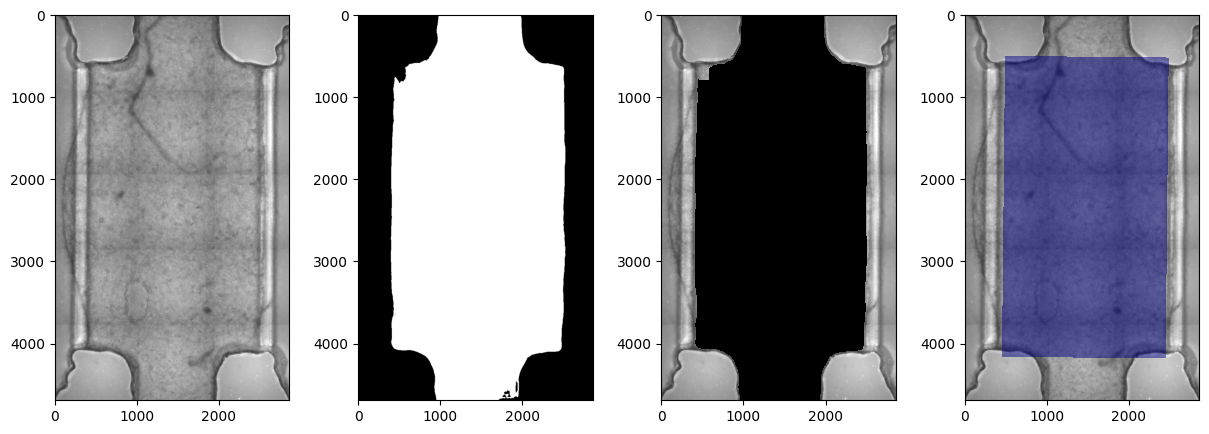

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(15,5))
ax[0].imshow(img_full, cmap='gray')
ax[1].imshow(mask_full, cmap='gray')
ax[2].imshow(img_full, cmap='gray')
ax[2].imshow(np.ma.masked_where(clean_mask == 0, clean_mask), cmap="gray")
ax[3].imshow(img_full, cmap='gray')
ax[3].imshow(np.ma.masked_where(rect_mask == 0, rect_mask), cmap="jet", alpha=0.5, interpolation="none")